In [109]:
import pandas as pd
import os

csv_file_path = '/content/train_u6lujuX_CVtuZ9i (1).csv'

df = pd.read_csv(csv_file_path)
print("Dataset loaded successfully.")
df.head()

Dataset loaded successfully.


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


# 2. Importing Libraries

In [110]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import missingno as mso
import seaborn as sns
import warnings
import os
import scipy

from scipy import stats
from scipy.stats import pearsonr
from scipy.stats import ttest_ind
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import CategoricalNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# 3. Reading Data Set 👓
👉 After importing libraries, we will also import the dataset that will be used.

In [111]:

csv_file_path = '/content/train_u6lujuX_CVtuZ9i (1).csv'
df = pd.read_csv(csv_file_path)
print("Dataset loaded successfully.")
df.head()

Dataset loaded successfully.


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [112]:
print(df.shape)

(614, 13)


# 4. Data Exploration

In [113]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [114]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ApplicantIncome,614.0,5403.459283,6109.041673,150.0,2877.5,3812.5,5795.00,81000.0
CoapplicantIncome,614.0,1621.245798,2926.248369,0.0,0.0,1188.5,2297.25,41667.0
LoanAmount,592.0,146.412162,85.587325,9.0,100.0,128.0,168.00,700.0
Loan_Amount_Term,600.0,342.000000,65.120410,12.0,360.0,360.0,360.00,480.0
Credit_History,564.0,0.842199,0.364878,0.0,1.0,1.0,1.00,1.0


In [115]:
# Define the models to be used
models = {
    'Logistic Regression': LogisticRegression(),
    'Categorical Naive Bayes': CategoricalNB(),
    'Random Forest': RandomForestClassifier(),
    'Neural Network': MLPClassifier(max_iter=500)
}

## 4.1 Categorical Variable

In [116]:
df.Loan_ID.value_counts(dropna=False)

,count
Loan_ID,
LP002990,1
LP001002,1
LP001003,1
LP001005,1
LP001006,1
...,...
LP001024,1
LP001020,1
LP001018,1


In [117]:
df.Gender.value_counts(dropna=False)

,count
Gender,
Male,489
Female,112
NaN,13


/tmp/ipython-input-2604761689.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Gender", data=df, palette="hls")


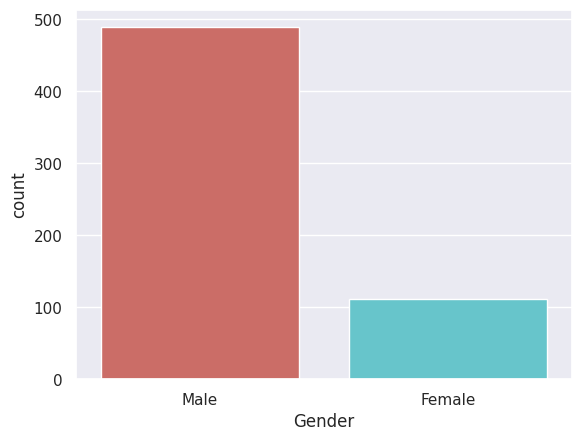

In [118]:
sns.countplot(x="Gender", data=df, palette="hls")
plt.show()

In [119]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

# Load data
data = pd.read_csv('train_u6lujuX_CVtuZ9i (1).csv')

# Encode categorical variables
le = LabelEncoder()
for col in ['Gender', 'Married', 'Dependents', 'Education',
            'Self_Employed', 'Property_Area', 'Loan_Status']:
    data[col] = le.fit_transform(data[col].astype(str))

# Split X and y
X = data.drop(['Loan_ID', 'Loan_Status'], axis=1)
y = data['Loan_Status']

# --- Handle Missing Values (imputation) ---
imputer = SimpleImputer(strategy='median')   # median works well with numeric + skewed data
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier()
}

# Train + Evaluate
for model_name, model in models.items():
    print(f"Training {model_name}...")
    model.fit(X_train, y_train)
    accuracy = model.score(X_test, y_test)
    print(f"Accuracy of {model_name}: {accuracy:.2%}\n")


Training Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy of Logistic Regression: 78.86%

Training Random Forest...
Accuracy of Random Forest: 76.42%



👉 From the results above, the number of male applicants is higher compared to female applicants. It also can be seen there are missing values in this column.

In [120]:
df.Married.value_counts(dropna=False)

,count
Married,
Yes,398
No,213
NaN,3


/tmp/ipython-input-3626669607.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Married", data=df, palette="Paired")


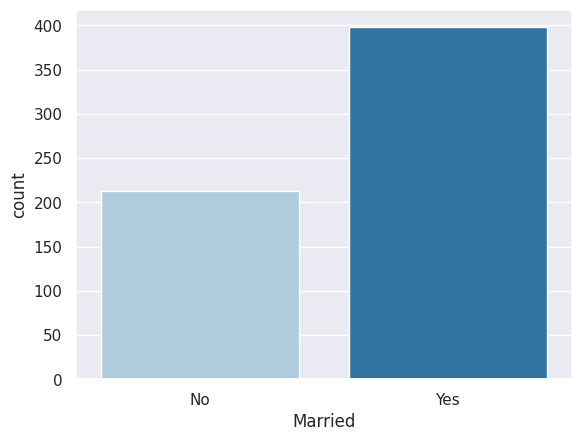

In [121]:
sns.countplot(x="Married", data=df, palette="Paired")
plt.show()

👉 The number of applicants that has been married is higher compared to applicants that hasn't married. It also can be seen there are small number of missing values in this column.

In [122]:
countMarried = len(df[df.Married == 'Yes'])
countNotMarried = len(df[df.Married == 'No'])
countNull = len(df[df.Married.isnull()])

print("Percentage of married: {:.2f}%".format((countMarried / (len(df.Married))*100)))
print("Percentage of Not married applicant: {:.2f}%".format((countNotMarried / (len(df.Married))*100)))
print("Missing values percentage: {:.2f}%".format((countNull / (len(df.Married))*100)))

Percentage of married: 64.82%
Percentage of Not married applicant: 34.69%
Missing values percentage: 0.49%


In [123]:
df.Education.value_counts(dropna=False)

,count
Education,
Graduate,480
Not Graduate,134


/tmp/ipython-input-4023769793.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Education", data=df, palette="rocket")


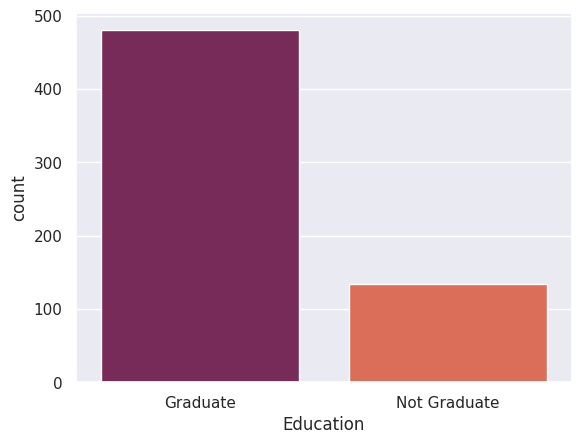

In [124]:
sns.countplot(x="Education", data=df, palette="rocket")
plt.show()

In [125]:
countGraduate = len(df[df.Education == 'Graduate'])
countNotGraduate = len(df[df.Education == 'Not Graduate'])
countNull = len(df[df.Education.isnull()])

print("Percentage of graduate applicant: {:.2f}%".format((countGraduate / (len(df.Education))*100)))
print("Percentage of Not graduate applicant: {:.2f}%".format((countNotGraduate / (len(df.Education))*100)))
print("Missing values percentage: {:.2f}%".format((countNull / (len(df.Education))*100)))

Percentage of graduate applicant: 78.18%
Percentage of Not graduate applicant: 21.82%
Missing values percentage: 0.00%


👉 The number of applicants that has been graduated is higher compared to applicants that hasn't graduated.

In [126]:
df.Self_Employed.value_counts(dropna=False)

,count
Self_Employed,
No,500
Yes,82
NaN,32


/tmp/ipython-input-1963651902.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Self_Employed", data=df, palette="crest")


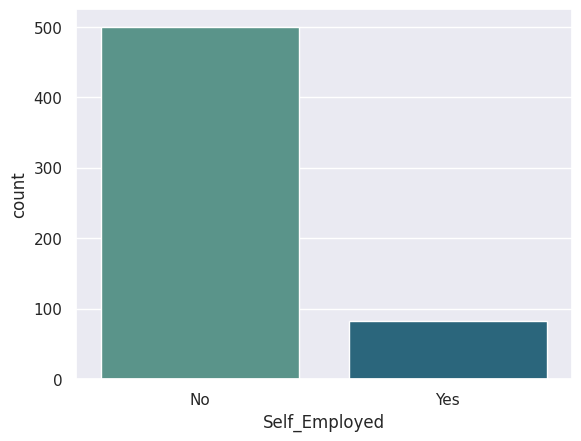

In [127]:
sns.countplot(x="Self_Employed", data=df, palette="crest")
plt.show()

In [128]:
countNo = len(df[df.Self_Employed == 'No'])
countYes = len(df[df.Self_Employed == 'Yes'])
countNull = len(df[df.Self_Employed.isnull()])

print("Percentage of Not self employed: {:.2f}%".format((countNo / (len(df.Self_Employed))*100)))
print("Percentage of self employed: {:.2f}%".format((countYes / (len(df.Self_Employed))*100)))
print("Missing values percentage: {:.2f}%".format((countNull / (len(df.Self_Employed))*100)))

Percentage of Not self employed: 81.43%
Percentage of self employed: 13.36%
Missing values percentage: 5.21%


👉 The number of applicants that are not self employed is higher compared to applicants that are self employed. It also can be seen, there are missing values in this column.

In [129]:
df.Credit_History.value_counts(dropna=False)

,count
Credit_History,
1.0,475
0.0,89
NaN,50


/tmp/ipython-input-261100619.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Credit_History", data=df, palette="viridis")


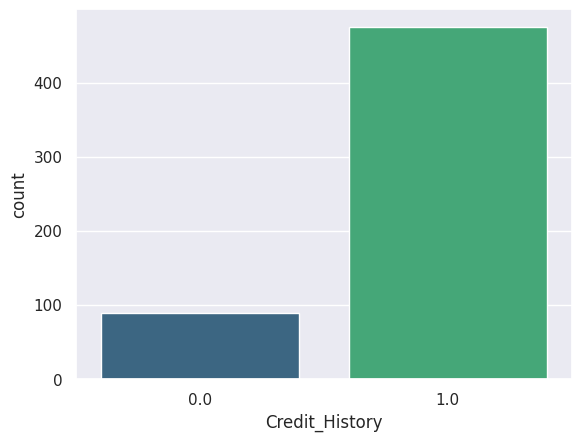

In [130]:
sns.countplot(x="Credit_History", data=df, palette="viridis")
plt.show()

In [131]:
count1 = len(df[df.Credit_History == 1])
count0 = len(df[df.Credit_History == 0])
countNull = len(df[df.Credit_History.isnull()])

print("Percentage of Good credit history: {:.2f}%".format((count1 / (len(df.Credit_History))*100)))
print("Percentage of Bad credit history: {:.2f}%".format((count0 / (len(df.Credit_History))*100)))
print("Missing values percentage: {:.2f}%".format((countNull / (len(df.Credit_History))*100)))

Percentage of Good credit history: 77.36%
Percentage of Bad credit history: 14.50%
Missing values percentage: 8.14%


👉 The number of applicants that have good credit history is higher compared to applicants that have bad credit history. It also can be seen, there are missing values in this column.

In [132]:
df.Property_Area.value_counts(dropna=False)

,count
Property_Area,
Semiurban,233
Urban,202
Rural,179


/tmp/ipython-input-1765907190.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Property_Area", data=df, palette="cubehelix")


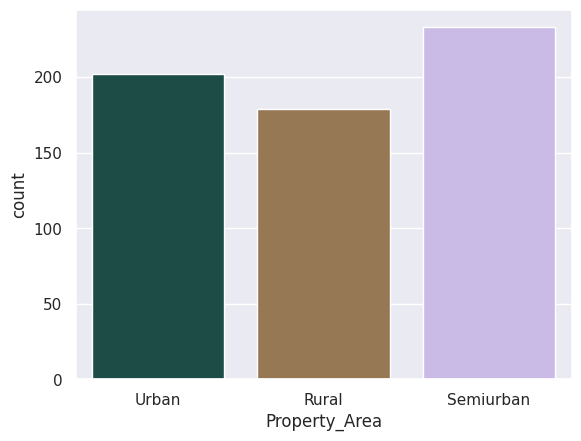

In [133]:
sns.countplot(x="Property_Area", data=df, palette="cubehelix")
plt.show()

In [134]:
countUrban = len(df[df.Property_Area == 'Urban'])
countRural = len(df[df.Property_Area == 'Rural'])
countSemiurban = len(df[df.Property_Area == 'Semiurban'])
countNull = len(df[df.Property_Area.isnull()])

print("Percentage of Urban: {:.2f}%".format((countUrban / (len(df.Property_Area))*100)))
print("Percentage of Rural: {:.2f}%".format((countRural / (len(df.Property_Area))*100)))
print("Percentage of Semiurban: {:.2f}%".format((countSemiurban / (len(df.Property_Area))*100)))
print("Missing values percentage: {:.2f}%".format((countNull / (len(df.Property_Area))*100)))

Percentage of Urban: 32.90%
Percentage of Rural: 29.15%
Percentage of Semiurban: 37.95%
Missing values percentage: 0.00%


👉 This column has a balanced distribution between Urban, Rural, and Semiurban property area. It also can be seen there is no missing value.

In [135]:
df.Loan_Status.value_counts(dropna=False)

,count
Loan_Status,
Y,422
N,192


/tmp/ipython-input-1110804027.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Loan_Status", data=df, palette="YlOrBr")


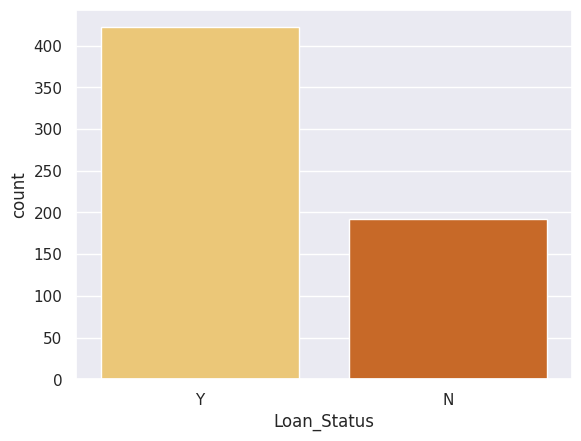

In [136]:
sns.countplot(x="Loan_Status", data=df, palette="YlOrBr")
plt.show()

In [137]:
countY = len(df[df.Loan_Status == 'Y'])
countN = len(df[df.Loan_Status == 'N'])
countNull = len(df[df.Loan_Status.isnull()])

print("Percentage of Approved: {:.2f}%".format((countY / (len(df.Loan_Status))*100)))
print("Percentage of Rejected: {:.2f}%".format((countN / (len(df.Loan_Status))*100)))
print("Missing values percentage: {:.2f}%".format((countNull / (len(df.Loan_Status))*100)))

Percentage of Approved: 68.73%
Percentage of Rejected: 31.27%
Missing values percentage: 0.00%


👉 The number of approved loans is higher compared to rejected loans . It also can be seen, there is no missing values in this column.

In [138]:
df.Loan_Amount_Term.value_counts(dropna=False)

,count
Loan_Amount_Term,
360.0,512
180.0,44
480.0,15
NaN,14
300.0,13
84.0,4
240.0,4
120.0,3
60.0,2


/tmp/ipython-input-32458805.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Loan_Amount_Term", data=df, palette="rocket")


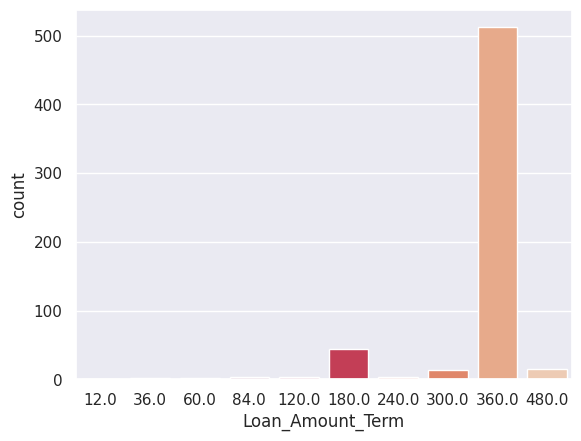

In [139]:
sns.countplot(x="Loan_Amount_Term", data=df, palette="rocket")
plt.show()

In [140]:
count12 = len(df[df.Loan_Amount_Term == 12.0])
count36 = len(df[df.Loan_Amount_Term == 36.0])
count60 = len(df[df.Loan_Amount_Term == 60.0])
count84 = len(df[df.Loan_Amount_Term == 84.0])
count120 = len(df[df.Loan_Amount_Term == 120.0])
count180 = len(df[df.Loan_Amount_Term == 180.0])
count240 = len(df[df.Loan_Amount_Term == 240.0])
count300 = len(df[df.Loan_Amount_Term == 300.0])
count360 = len(df[df.Loan_Amount_Term == 360.0])
count480 = len(df[df.Loan_Amount_Term == 480.0])
countNull = len(df[df.Loan_Amount_Term.isnull()])

print("Percentage of 12: {:.2f}%".format((count12 / (len(df.Loan_Amount_Term))*100)))
print("Percentage of 36: {:.2f}%".format((count36 / (len(df.Loan_Amount_Term))*100)))
print("Percentage of 60: {:.2f}%".format((count60 / (len(df.Loan_Amount_Term))*100)))
print("Percentage of 84: {:.2f}%".format((count84 / (len(df.Loan_Amount_Term))*100)))
print("Percentage of 120: {:.2f}%".format((count120 / (len(df.Loan_Amount_Term))*100)))
print("Percentage of 180: {:.2f}%".format((count180 / (len(df.Loan_Amount_Term))*100)))
print("Percentage of 240: {:.2f}%".format((count240 / (len(df.Loan_Amount_Term))*100)))
print("Percentage of 300: {:.2f}%".format((count300 / (len(df.Loan_Amount_Term))*100)))
print("Percentage of 360: {:.2f}%".format((count360 / (len(df.Loan_Amount_Term))*100)))
print("Percentage of 480: {:.2f}%".format((count480 / (len(df.Loan_Amount_Term))*100)))
print("Missing values percentage: {:.2f}%".format((countNull / (len(df.Loan_Amount_Term))*100)))

Percentage of 12: 0.16%
Percentage of 36: 0.33%
Percentage of 60: 0.33%
Percentage of 84: 0.65%
Percentage of 120: 0.49%
Percentage of 180: 7.17%
Percentage of 240: 0.65%
Percentage of 300: 2.12%
Percentage of 360: 83.39%
Percentage of 480: 2.44%
Missing values percentage: 2.28%


In [141]:
# استخراج الأعمدة التصنيفية تلقائياً من df
categorical_features = df.select_dtypes(include=['object', 'category']).columns.tolist()
categorical_features


['Loan_ID',
 'Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'Property_Area',
 'Loan_Status']

👉 As can be seen from the results, **the 360 days loan duration is the most popular** compared to others.

In [142]:
# Create an DataFrame for Analysis Categorical Features
result_df = pd.DataFrame(columns=['Features', 'Category', 'Count'])

for col in categorical_features:
    # Get the value counts for the column
    value_counts = df[col].value_counts().reset_index()
    value_counts.columns = ['Category', 'Count']
    value_counts['Features'] = col
    result_df = pd.concat([result_df, value_counts], ignore_index=True)

# Display the result
grouped_df = result_df.groupby('Features').agg({'Category': list, 'Count': list})
grouped_df

,Category,Count
Features,,
Dependents,"[0, 1, 2, 3+]","[345, 102, 101, 51]"
Education,"[Graduate, Not Graduate]","[480, 134]"
Gender,"[Male, Female]","[489, 112]"
Loan_ID,"[LP002990, LP001002, LP001003, LP001005, LP001...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
Loan_Status,"[Y, N]","[422, 192]"
Married,"[Yes, No]","[398, 213]"
Property_Area,"[Semiurban, Urban, Rural]","[233, 202, 179]"
Self_Employed,"[No, Yes]","[500, 82]"


## 4.2 Numerical Variable

In [143]:
df[['ApplicantIncome','CoapplicantIncome','LoanAmount']].describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount
count,614.000000,614.000000,592.000000
mean,5403.459283,1621.245798,146.412162
std,6109.041673,2926.248369,85.587325
min,150.000000,0.000000,9.000000
25%,2877.500000,0.000000,100.000000
50%,3812.500000,1188.500000,128.000000
75%,5795.000000,2297.250000,168.000000
max,81000.000000,41667.000000,700.000000


#### 4.2.2.1 Histogram Distribution 📉

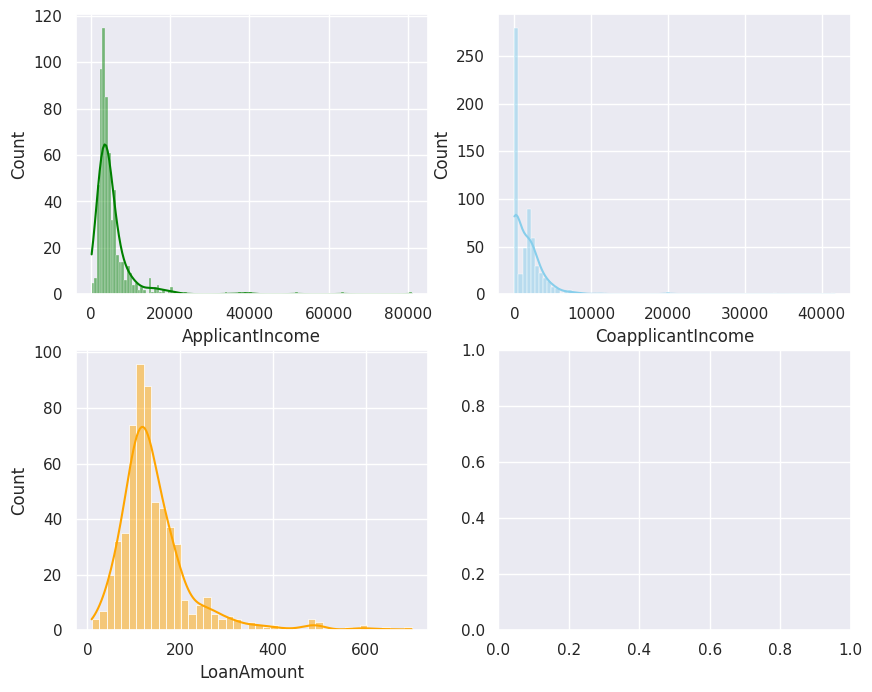

In [144]:
sns.set(style="darkgrid")
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

sns.histplot(data=df, x="ApplicantIncome", kde=True, ax=axs[0, 0], color='green')
sns.histplot(data=df, x="CoapplicantIncome", kde=True, ax=axs[0, 1], color='skyblue')
sns.histplot(data=df, x="LoanAmount", kde=True, ax=axs[1, 0], color='orange');

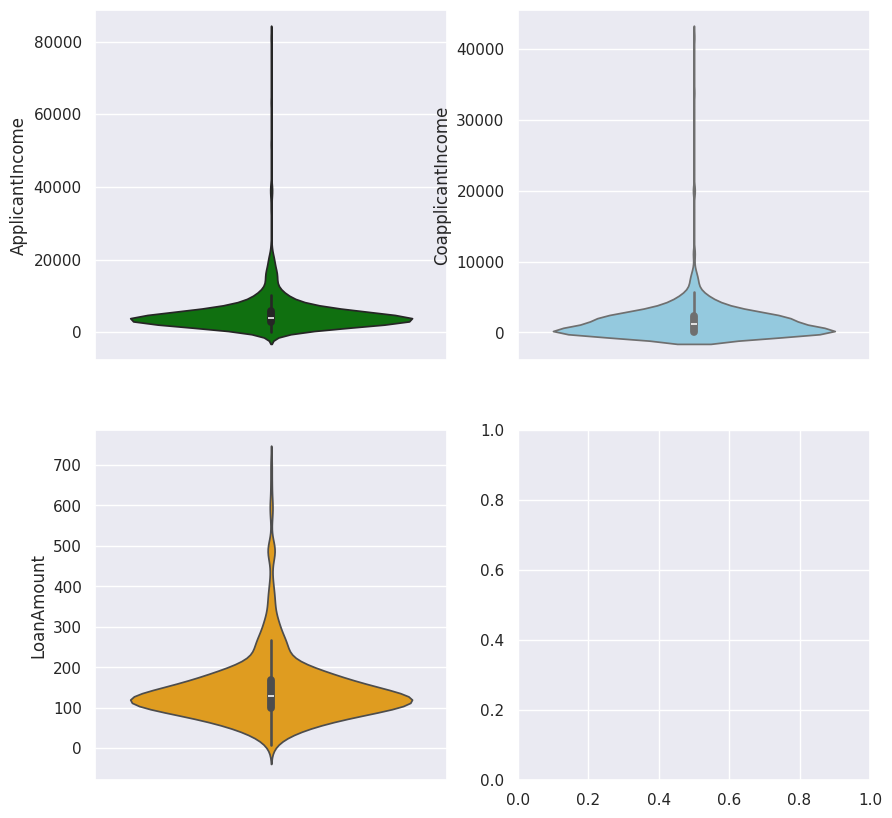

In [145]:
sns.set(style="darkgrid")
fig, axs1 = plt.subplots(2, 2, figsize=(10, 10))

sns.violinplot(data=df, y="ApplicantIncome", ax=axs1[0, 0], color='green')
sns.violinplot(data=df, y="CoapplicantIncome", ax=axs1[0, 1], color='skyblue')
sns.violinplot(data=df, y="LoanAmount", ax=axs1[1, 0], color='orange');

*   The distribution of **Applicant income, Co Applicant Income, and Loan Amount** are **positively skewed** and **it has outliers** (can be seen from both histogram and violin plot).
*   The distribution of **Loan Amount Term** is **negativly skewed** and **it has outliers.**



## 4.3 Other Exploration
 This section will show additional exploration from each variables. The additional exploration are:
*   Bivariate analysis (categorical w/ categorical, categroical w/ numerical, and numerical w/ numerical)
*   Heatmap



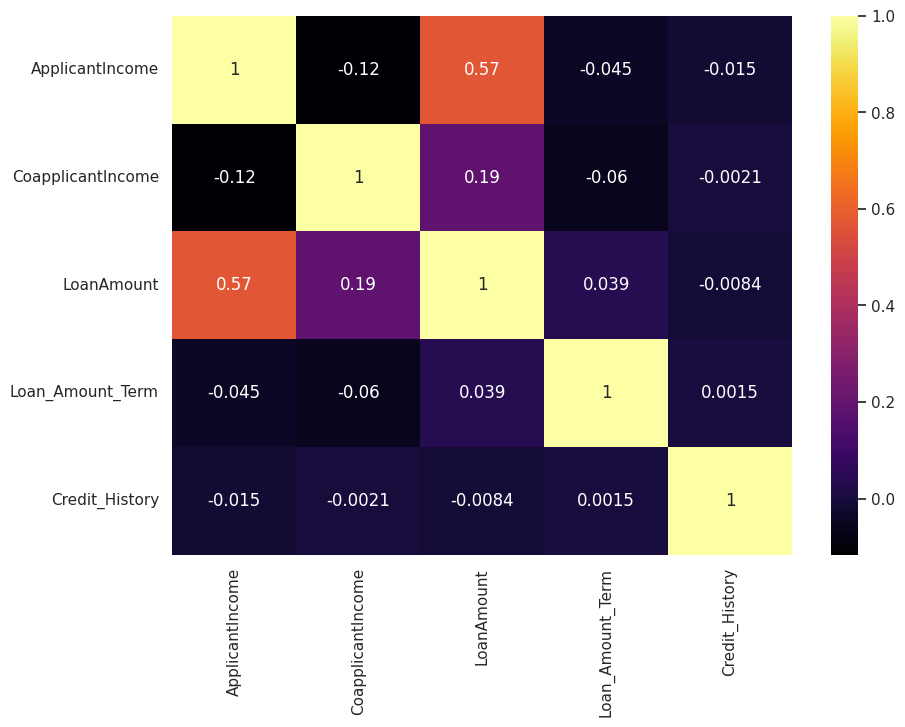

In [146]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,7))
sns.heatmap(numeric_df.corr(), annot=True, cmap='inferno')
plt.show()


👉 There is positive correlation between Loan Amount and Applicant Income

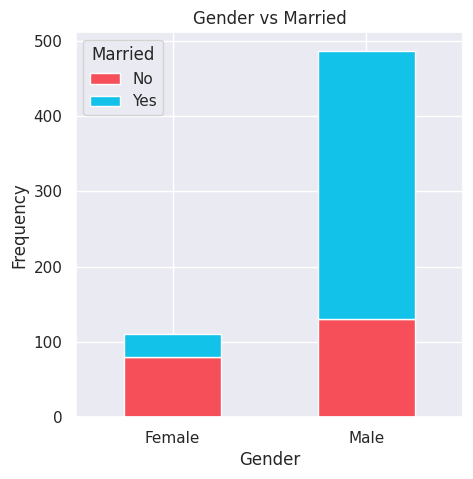

In [147]:
pd.crosstab(df.Gender,df.Married).plot(kind="bar", stacked=True, figsize=(5,5), color=['#f64f59','#12c2e9'])
plt.title('Gender vs Married')
plt.xlabel('Gender')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
plt.show()

👉 Most male applicants are already married compared to female applicants. Also, the number of not married male applicants are higher compare to female applicants that had not married.

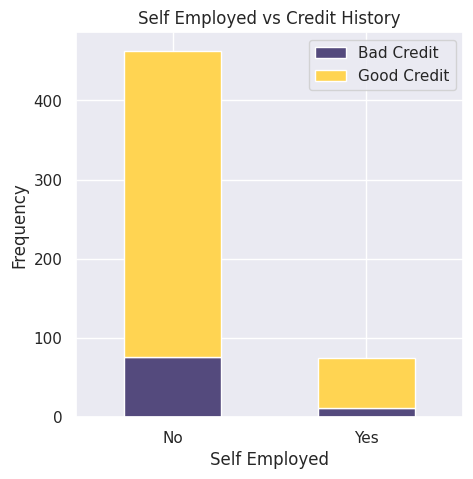

In [148]:
pd.crosstab(df.Self_Employed,df.Credit_History).plot(kind="bar", stacked=True, figsize=(5,5), color=['#544a7d','#ffd452'])
plt.title('Self Employed vs Credit History')
plt.xlabel('Self Employed')
plt.ylabel('Frequency')
plt.legend(["Bad Credit", "Good Credit"])
plt.xticks(rotation=0)
plt.show()

👉 Most not self employed applicants have good credit compared to self employed applicants.

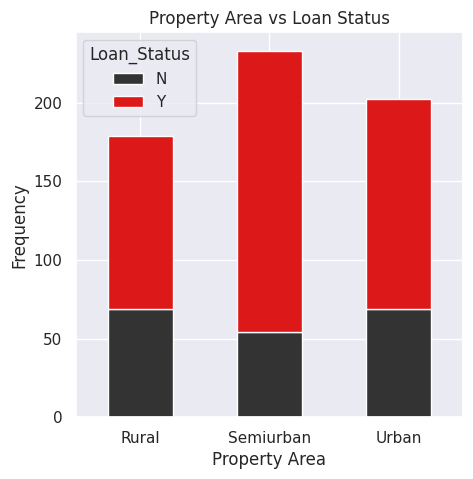

In [149]:
pd.crosstab(df.Property_Area,df.Loan_Status).plot(kind="bar", stacked=True, figsize=(5,5), color=['#333333','#dd1818'])
plt.title('Property Area vs Loan Status')
plt.xlabel('Property Area')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
plt.show()

👉 Most of loan that got accepted has property in Semiurban compared to Urban and Rural.

/tmp/ipython-input-1139030696.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Loan_Status", y="ApplicantIncome", data=df, palette="mako");


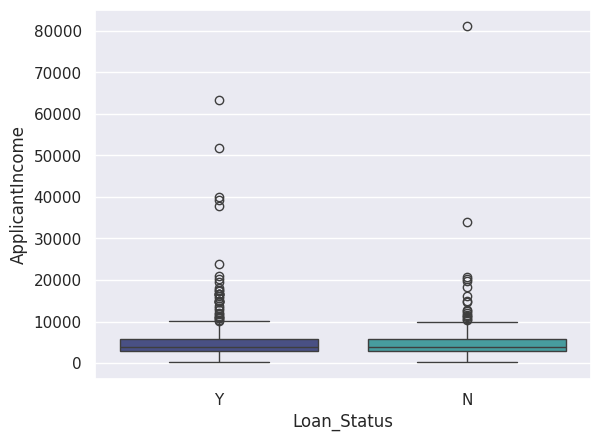

In [150]:
sns.boxplot(x="Loan_Status", y="ApplicantIncome", data=df, palette="mako");

👉 It can be seen that there are lots of outliers in Applicant Income, and the distribution also positively skewed

/tmp/ipython-input-3243319138.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="CoapplicantIncome", y="Loan_Status", data=df, palette="rocket");


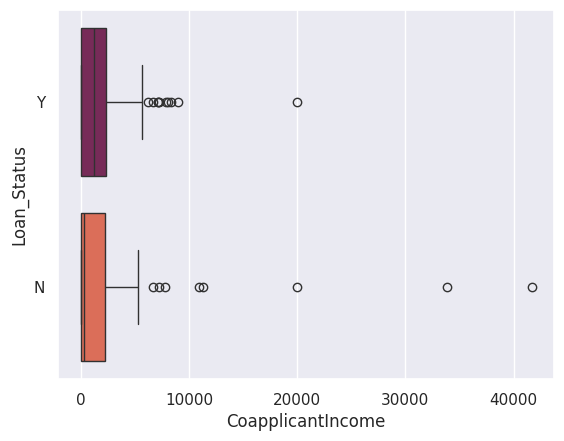

In [151]:
sns.boxplot(x="CoapplicantIncome", y="Loan_Status", data=df, palette="rocket");

👉 It's clear that Co Applicant Income has a number of outliers, and the distribution is also positively skewed.

/tmp/ipython-input-2807477037.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Loan_Status", y="LoanAmount", data=df, palette="YlOrBr");


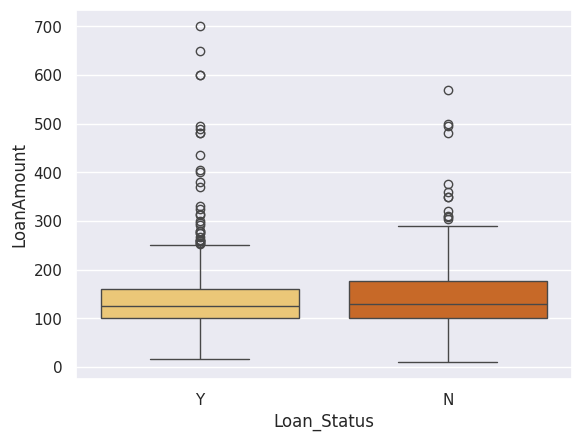

In [152]:
sns.boxplot(x="Loan_Status", y="LoanAmount", data=df, palette="YlOrBr");

👉 As can be seen, Co Applicant Income has a high number of outliers, and the distribution is also positively skewed.

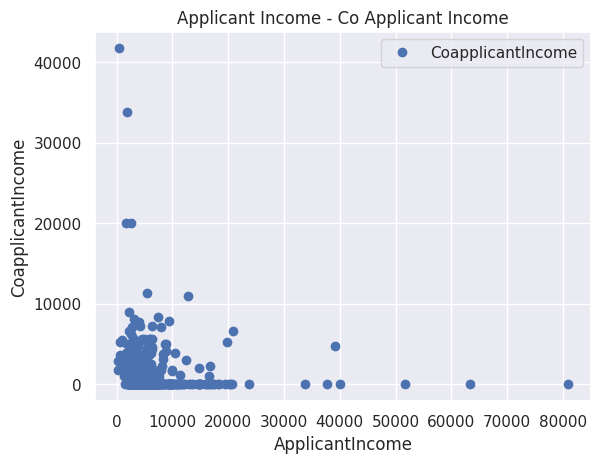

Pearson correlation: -0.11660458122889966
T Test and P value: 
 TtestResult(statistic=np.float64(13.835753259915665), pvalue=np.float64(1.460983948423972e-40), df=np.float64(1226.0))


In [153]:
df.plot(x='ApplicantIncome', y='CoapplicantIncome', style='o')
plt.title('Applicant Income - Co Applicant Income')
plt.xlabel('ApplicantIncome')
plt.ylabel('CoapplicantIncome')
plt.show()
print('Pearson correlation:', df['ApplicantIncome'].corr(df['CoapplicantIncome']))
print('T Test and P value: \n', stats.ttest_ind(df['ApplicantIncome'], df['CoapplicantIncome']))

*   There is **negative correlation** between Applicant income and Co Applicant Income.
*   The correlation coefficient is **significant** at the 95 per cent confidence interval, as it has a **p-value of 1.46**


## 4.4 Null Values 🚫

In [154]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


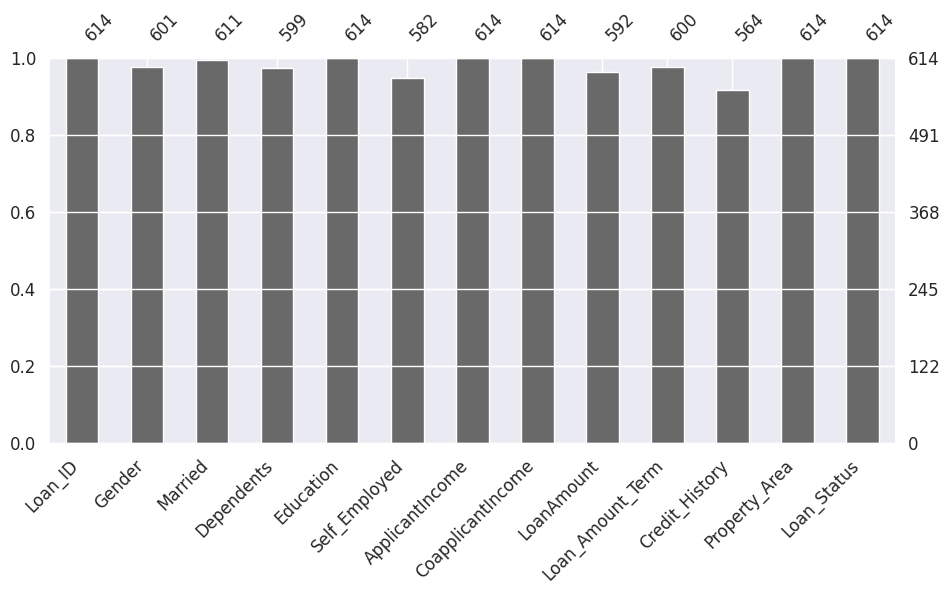

In [155]:
plt.figure(figsize = (24, 5))
axz = plt.subplot(1,2,2)
mso.bar(df, ax = axz, fontsize = 12);

In [156]:
# Finding Rows with 50% or More Null Values in each sets

def find_rows_with_high_null_values(df):
    threshold = 0.5
    # Getting DataFrame Name
    df_name = [name for name in globals() if globals()[name] is df][0]
    null_threshold = int(threshold * len(df.columns))
    null_rows = df[df.apply(lambda x: x.isnull().sum(), axis=1) >= null_threshold]
    num_null_rows = len(null_rows)
    print(f"The number of rows consisting of more than 50% missing values in {df_name} is: {num_null_rows}")

# Example usage:
find_rows_with_high_null_values(df)

The number of rows consisting of more than 50% missing values in df is: 0


# 5. Data Preprocessing ⚙

In [157]:
df = df.drop(['Loan_ID'], axis = 1)

In [158]:
# Remove duplicates based on all columns
print(f'Shape of Loan Dataset before drop duplicated Row is: {df.shape}')
df = df.drop_duplicates()
print(f'Shape of Loan Dataset After Drop Duplicated Row is: {df.shape}')

Shape of Loan Dataset before drop duplicated Row is: (614, 12)
Shape of Loan Dataset After Drop Duplicated Row is: (614, 12)


## 5.2 Data Imputation 📝
👉 Imputation is a technique for substituting an estimated value for missing values in a dataset. In this section, the imputation will be performed for variables that have missing values.

In [159]:
df['Gender'].fillna(df['Gender'].mode()[0],inplace=True)
df['Married'].fillna(df['Married'].mode()[0],inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0],inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0],inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0],inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0],inplace=True)

/tmp/ipython-input-3023607144.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].fillna(df['Gender'].mode()[0],inplace=True)
/tmp/ipython-input-3023607144.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

In [160]:
df['LoanAmount'].fillna(df['LoanAmount'].mean(),inplace=True)

/tmp/ipython-input-2424903021.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['LoanAmount'].fillna(df['LoanAmount'].mean(),inplace=True)


## 5.3 One-hot Encoding 🔧
👉 In this section, I will **transform categorical variables into a form that could be provided by ML algorithms to do a better prediction.**

### Convert Categorical Features

In machine learning problems, categorical features are crucial, and the operations we perform on them significantly impact the quality and final results. Many machine learning algorithms require numeric input, and we cannot provide them with feature values as strings. Therefore, it is necessary to convert categorical features into numbers before using them with machine learning algorithms.

Categorical features can be divided into the following four main groups:

**Nominal:** These consist of two or more categories that have no inherent order between their values. For example, "gender" is a nominal variable.

**Ordinal:** These have a specific order or hierarchy between the values of the groups. For example, age groups such as "young," "middle-aged," and "old" are ordinal variables.
Tips:

Before working with categorical features, it is essential to fill in any missing values.

**If the feature is of the "nominal" type,** use One-Hot Encoding. If the number of categories is large, consider using Label Encoding to prevent an excessive increase in the number of features.

**If the feature is of the "ordinal" type,** represent them as meaningful numbers.
In this dataset, we have seven categorical features, one of which is ordinal, and the remaining six are nominal.

In [161]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,146.412162,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.000000,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.000000,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.000000,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.000000,360.0,1.0,Urban,Y


## Handle Nominal Feature

In [162]:
Nominal_fetaures = ['Gender', 'Married','Education', 'Self_Employed', 'Property_Area']

In [163]:
# Encoding Categorical Features
def encode_categorical_features(df, cols):

    for col in cols:
        dummies = pd.get_dummies(df[col], dtype=int, prefix=col)
        df = pd.concat([df, dummies], axis=1)
        df = df.drop(labels=col, axis=1)
    return df

# Encode the categorical features in the training and test sets
df = encode_categorical_features(df, Nominal_fetaures)
df.head()

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Gender_Female,Gender_Male,Married_No,Married_Yes,Education_Graduate,Education_Not Graduate,Self_Employed_No,Self_Employed_Yes,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,0,5849,0.0,146.412162,360.0,1.0,Y,0,1,1,0,1,0,1,0,0,0,1
1,1,4583,1508.0,128.000000,360.0,1.0,N,0,1,0,1,1,0,1,0,1,0,0
2,0,3000,0.0,66.000000,360.0,1.0,Y,0,1,0,1,1,0,0,1,0,0,1
3,0,2583,2358.0,120.000000,360.0,1.0,Y,0,1,0,1,0,1,1,0,0,0,1
4,0,6000,0.0,141.000000,360.0,1.0,Y,0,1,1,0,1,0,1,0,0,0,1


## Handle Ordinal Feature

In [164]:
# Encoding Categorical Features
encoder = {'0': 1/4, '1': 2/4, '2': 3/4, '3+': 4/4}
df["Dependents"] = df['Dependents'].map(encoder)

df.head()

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Gender_Female,Gender_Male,Married_No,Married_Yes,Education_Graduate,Education_Not Graduate,Self_Employed_No,Self_Employed_Yes,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,0.25,5849,0.0,146.412162,360.0,1.0,Y,0,1,1,0,1,0,1,0,0,0,1
1,0.50,4583,1508.0,128.000000,360.0,1.0,N,0,1,0,1,1,0,1,0,1,0,0
2,0.25,3000,0.0,66.000000,360.0,1.0,Y,0,1,0,1,1,0,0,1,0,0,1
3,0.25,2583,2358.0,120.000000,360.0,1.0,Y,0,1,0,1,0,1,1,0,0,0,1
4,0.25,6000,0.0,141.000000,360.0,1.0,Y,0,1,1,0,1,0,1,0,0,0,1


In [165]:
# Convet target column to int
mapping = {'Y': 1,'N': 0}
df["Loan_Status"] = df['Loan_Status'].map(mapping)

df.head()

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Gender_Female,Gender_Male,Married_No,Married_Yes,Education_Graduate,Education_Not Graduate,Self_Employed_No,Self_Employed_Yes,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,0.25,5849,0.0,146.412162,360.0,1.0,1,0,1,1,0,1,0,1,0,0,0,1
1,0.50,4583,1508.0,128.000000,360.0,1.0,0,0,1,0,1,1,0,1,0,1,0,0
2,0.25,3000,0.0,66.000000,360.0,1.0,1,0,1,0,1,1,0,0,1,0,0,1
3,0.25,2583,2358.0,120.000000,360.0,1.0,1,0,1,0,1,0,1,1,0,0,0,1
4,0.25,6000,0.0,141.000000,360.0,1.0,1,0,1,1,0,1,0,1,0,0,0,1


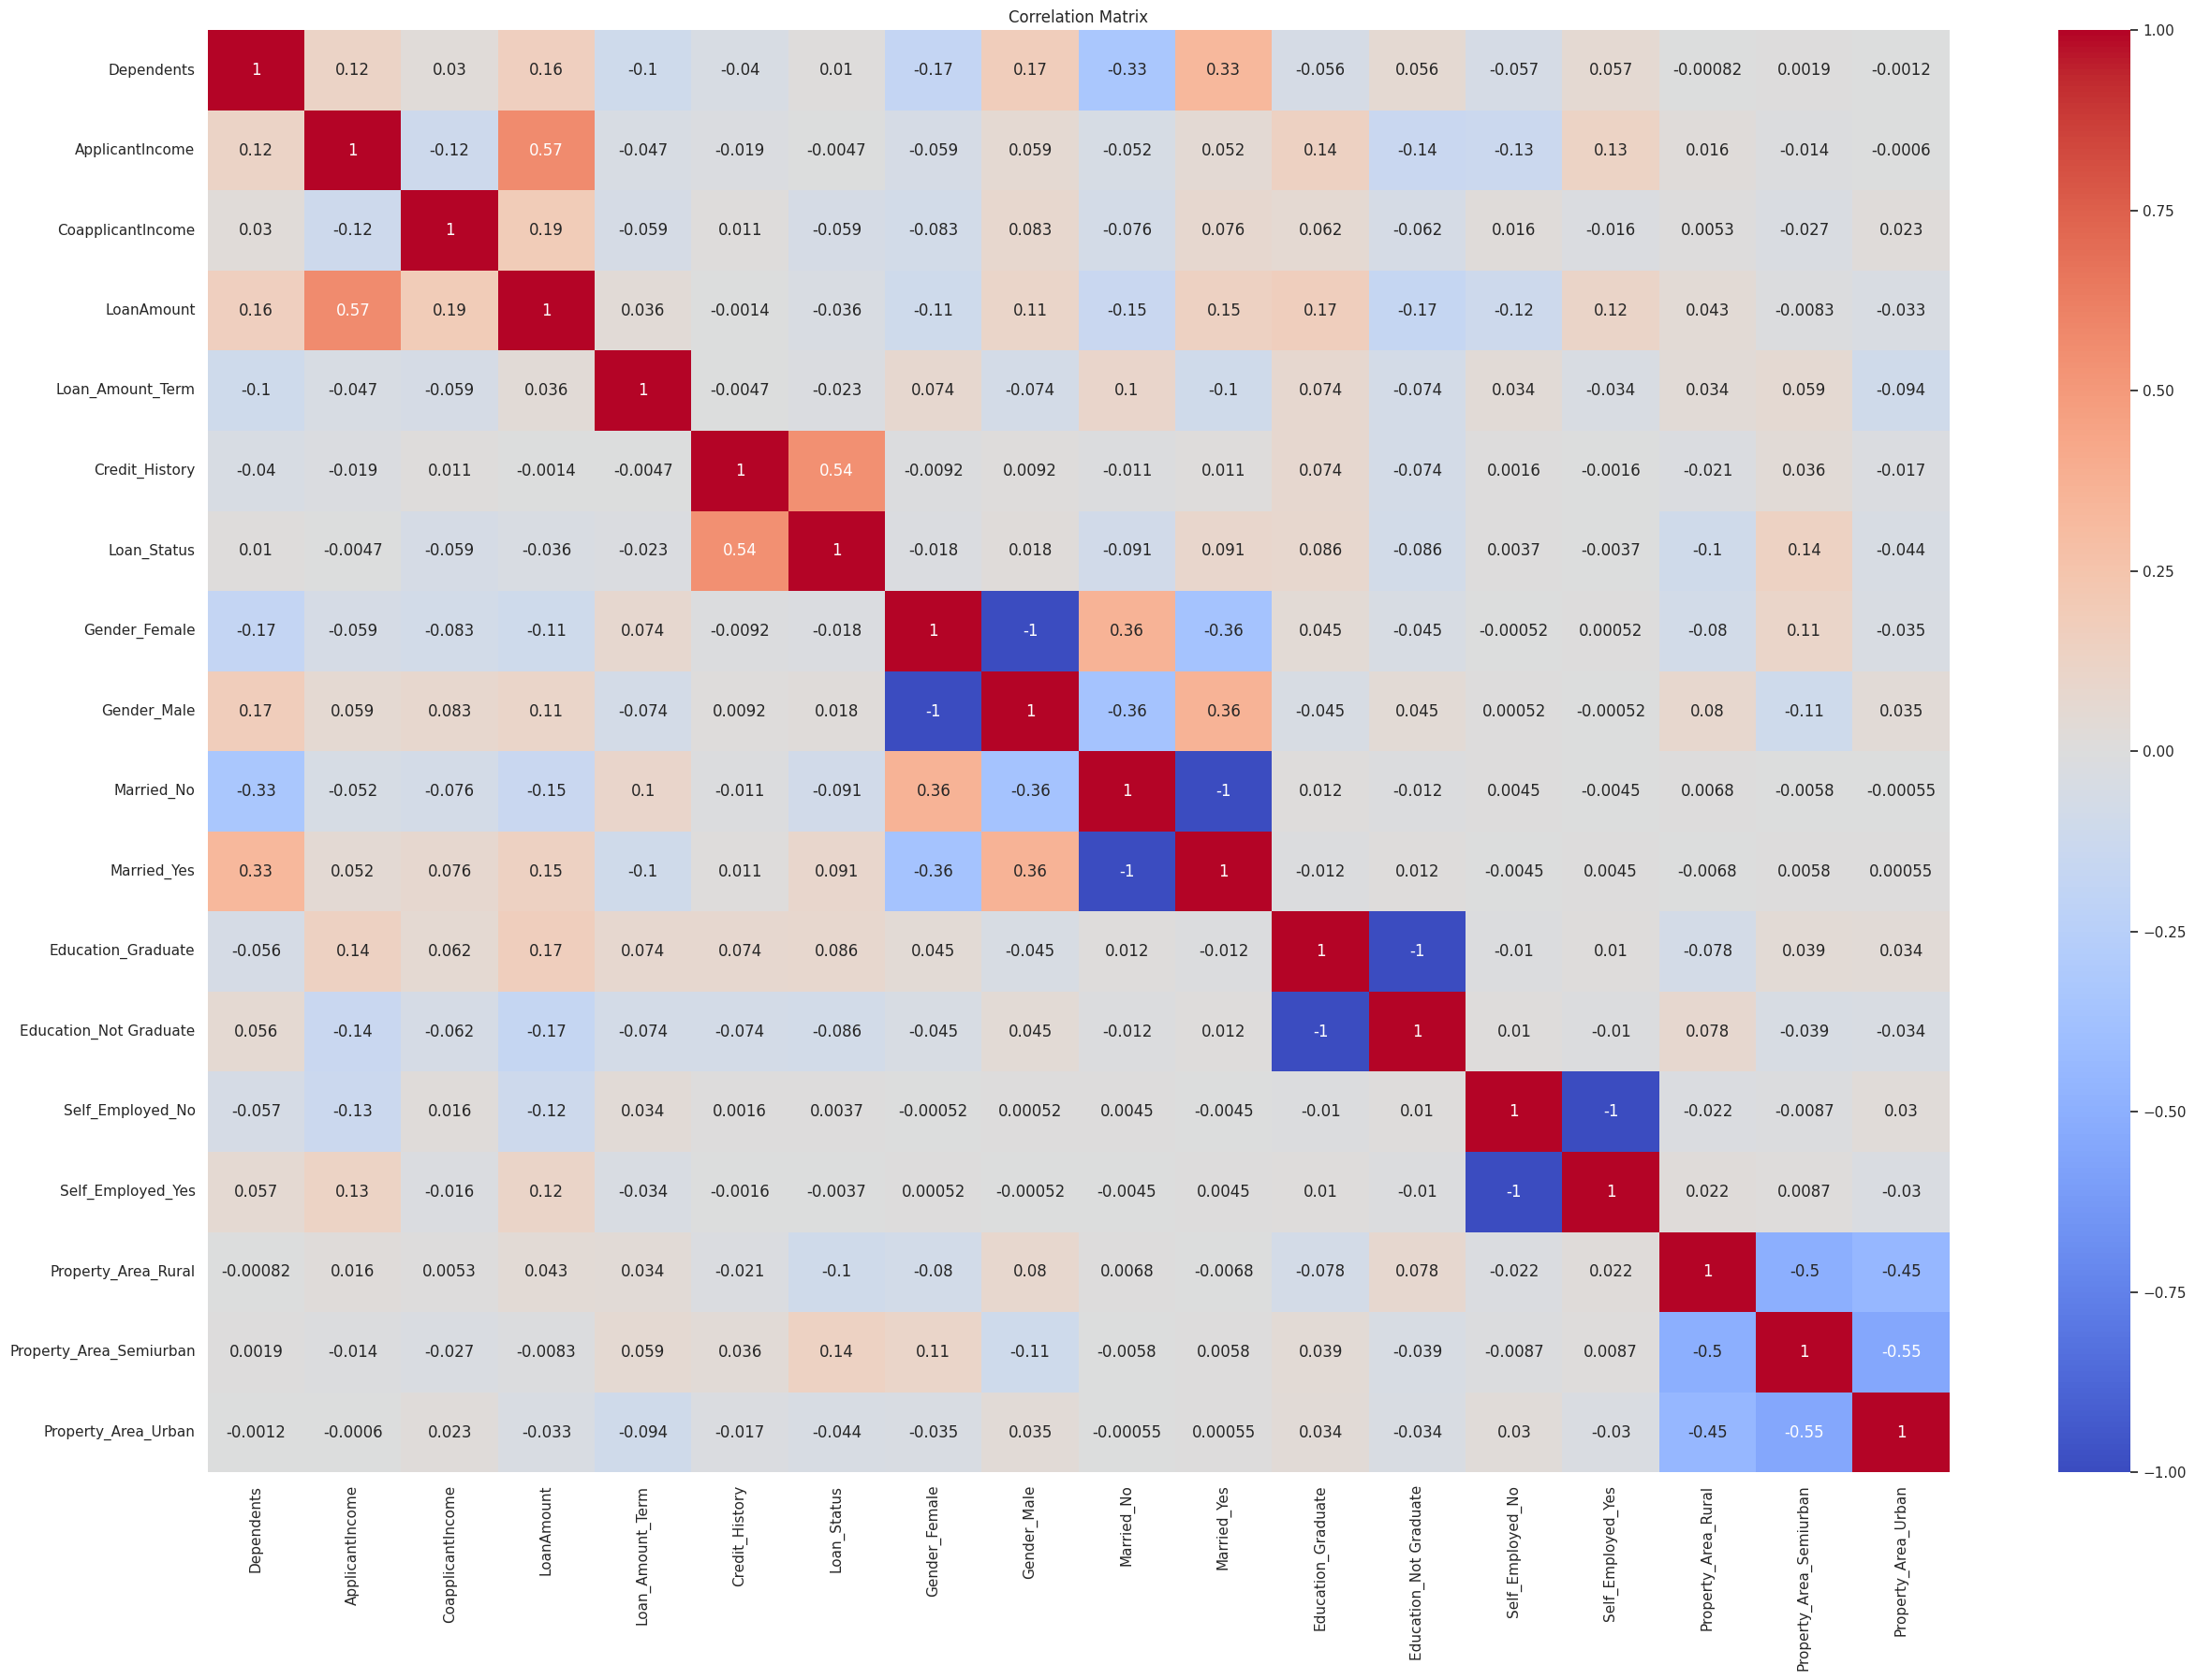

In [166]:
corr_matrix =df.corr()
fig, ax = plt.subplots(figsize=(30, 20))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True, ax=ax)
ax.set_title('Correlation Matrix')
plt.show()

## 5.3 Remove Outliers & Infinite values 🚮
👉 Since there are outliers, **the outliers will be removed**. <br>


In [167]:
df.shape

(614, 18)

In [168]:
# Q1 = df.quantile(0.25)
# Q3 = df.quantile(0.75)
# IQR = Q3 - Q1

# df = df[~((df < (Q1 - 1.5 * IQR)) |(df > (Q3 + 1.5 * IQR))).any(axis=1)]

In [169]:
df.shape

(614, 18)

## 5.4 Skewed Distribution Treatment 📐
👉 In previous section, it already shown that **distribution for ApplicantIncome, CoapplicantIncome, and LoanAmount is positively skewed**. <br>
👉 I will use **square root transformation** to normalized the distribution.

In [170]:
# Square Root Transformation
df.ApplicantIncome = np.sqrt(df.ApplicantIncome)
df.CoapplicantIncome = np.sqrt(df.CoapplicantIncome)
df.LoanAmount = np.sqrt(df.LoanAmount)

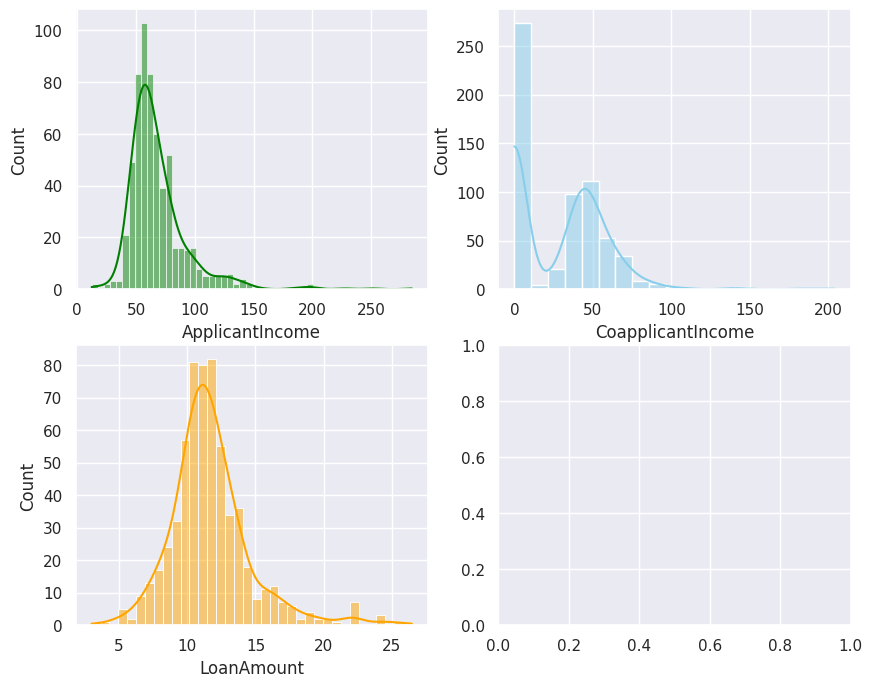

In [171]:
sns.set(style="darkgrid")
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

sns.histplot(data=df, x="ApplicantIncome", kde=True, ax=axs[0, 0], color='green')
sns.histplot(data=df, x="CoapplicantIncome", kde=True, ax=axs[0, 1], color='skyblue')
sns.histplot(data=df, x="LoanAmount", kde=True, ax=axs[1, 0], color='orange');

👉 As can be seen, the distribution after using log transformation are much better compared to original distribution.

## 5.5 Features Separating ➗
👉 Dependent features (Loan_Status) will be seperated from independent features.

In [172]:
df.shape

(614, 18)

/tmp/ipython-input-1141482665.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=y, data=X, palette="coolwarm")


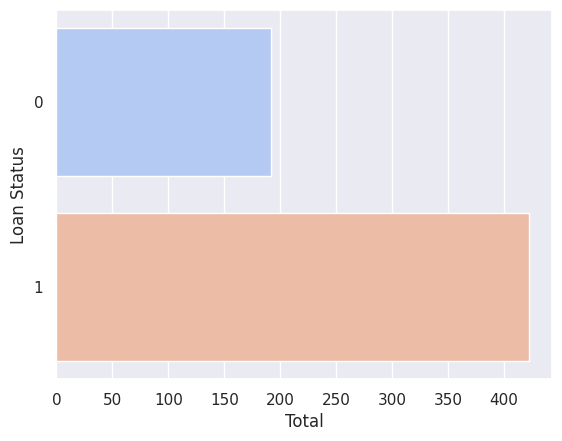

In [173]:
X = df.drop(["Loan_Status"], axis=1)
y = df["Loan_Status"]
sns.set_theme(style="darkgrid")
sns.countplot(y=y, data=X, palette="coolwarm")
plt.ylabel('Loan Status')
plt.xlabel('Total')
plt.show()

In [174]:
X.shape

(614, 17)

## 5.6 SMOTE Technique
In previous exploration, it can be seen that **the number between approved and rejected loan is imbalanced**. In this section, **oversampling technique will be used to avoid overfitting**,

/tmp/ipython-input-695642574.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=y, data=X, palette="coolwarm")


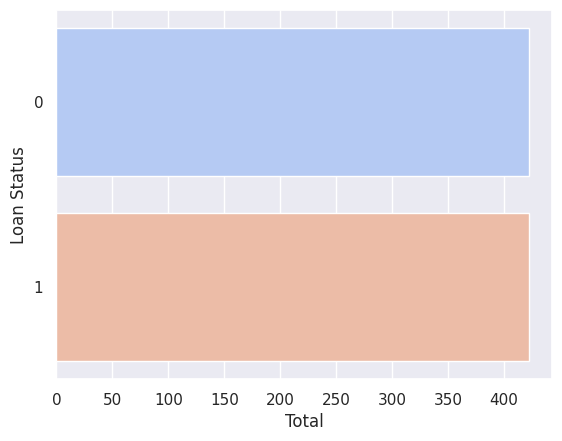

In [175]:
X, y = SMOTE().fit_resample(X, y)
sns.set_theme(style="darkgrid")
sns.countplot(y=y, data=X, palette="coolwarm")
plt.ylabel('Loan Status')
plt.xlabel('Total')
plt.show()

In [176]:
X.shape

(844, 17)

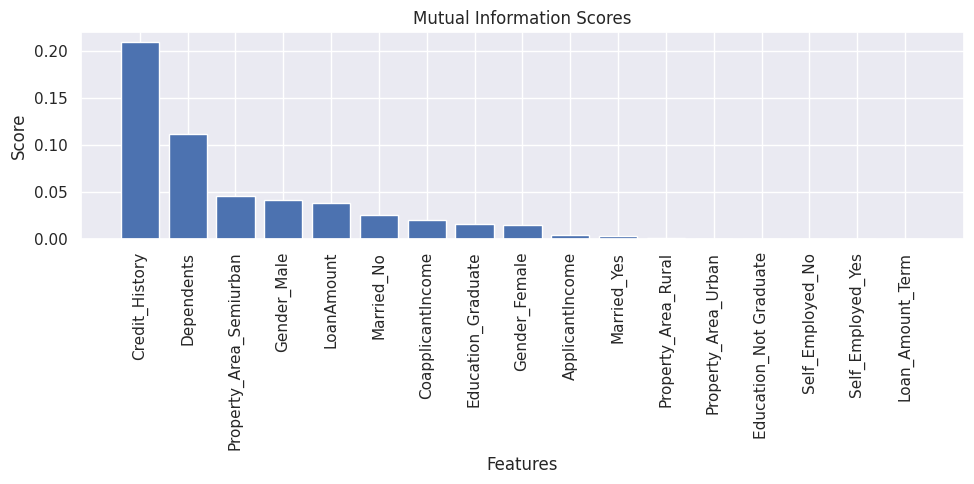

In [177]:
from sklearn.feature_selection import mutual_info_classif
# Mutual Information
# Mutual Information
feature_names = X.columns
scores = mutual_info_classif(X, y)

# Create an array of indices for sorting the scores and feature names
indices = np.argsort(scores)[::-1]

# Sort the scores and feature names based on the indices
sorted_scores = scores[indices]
sorted_feature_names = [feature_names[i] for i in indices]

# Plot the bar chart
plt.figure(figsize=(10, 5))
plt.bar(range(len(sorted_scores)), sorted_scores)
plt.xticks(range(len(sorted_scores)), sorted_feature_names, rotation='vertical')
plt.title("Mutual Information Scores")
plt.xlabel("Features")
plt.ylabel("Score")
plt.tight_layout()
plt.show()

In [178]:
drop_fetaures=[]


mi_scores = sorted(zip(feature_names, scores), key=lambda x: x[1], reverse=True)

for feature, score in mi_scores:
    print(f"{feature}: {score:.4f}")
    if score<0.001:
        print(f"Dropping The Feature{feature}")
        drop_fetaures.append(feature)

drop_fetaures

Credit_History: 0.2093
Dependents: 0.1119
Property_Area_Semiurban: 0.0449
Gender_Male: 0.0406
LoanAmount: 0.0376
Married_No: 0.0248
CoapplicantIncome: 0.0200
Education_Graduate: 0.0160
Gender_Female: 0.0142
ApplicantIncome: 0.0044
Married_Yes: 0.0031
Property_Area_Rural: 0.0003
Dropping The FeatureProperty_Area_Rural
Loan_Amount_Term: 0.0000
Dropping The FeatureLoan_Amount_Term
Education_Not Graduate: 0.0000
Dropping The FeatureEducation_Not Graduate
Self_Employed_No: 0.0000
Dropping The FeatureSelf_Employed_No
Self_Employed_Yes: 0.0000
Dropping The FeatureSelf_Employed_Yes
Property_Area_Urban: 0.0000
Dropping The FeatureProperty_Area_Urban


['Property_Area_Rural',
 'Loan_Amount_Term',
 'Education_Not Graduate',
 'Self_Employed_No',
 'Self_Employed_Yes',
 'Property_Area_Urban']

In [179]:
# Dropping Features with 0.0 scores in MI

def Dropping(df, cols):

    for col in cols:
        df = df.drop(labels=col, axis=1)
    return df

X_update = Dropping(X, drop_fetaures)

In [180]:
X_update.shape

(844, 11)

## *5.7 Data Normalization

In [181]:
X_scaled= MinMaxScaler().fit_transform(X_update)

In [182]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.2,
                                                    random_state = 0)
X_train.shape,y_train.shape

((675, 11), (675,))

In [183]:
X_test.shape,y_test.shape

((169, 11), (169,))

# 6. Models 🛠

## 6.1 Logistic Regression

In [184]:
LRclassifier = LogisticRegression(solver='saga', max_iter=500, random_state=1)
LRclassifier.fit(X_train, y_train)

y_pred = LRclassifier.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

from sklearn.metrics import accuracy_score
LRAcc = accuracy_score(y_pred,y_test)
print('LR accuracy: {:.2f}%'.format(LRAcc*100))

              precision    recall  f1-score   support

           0       0.98      0.58      0.73        86
           1       0.69      0.99      0.82        83

    accuracy                           0.78       169
   macro avg       0.84      0.78      0.77       169
weighted avg       0.84      0.78      0.77       169

[[50 36]
 [ 1 82]]
LR accuracy: 78.11%


In [185]:
from sklearn.neighbors import KNeighborsClassifier
import numpy as np


## 6.2 K-Nearest Neighbour (KNN)

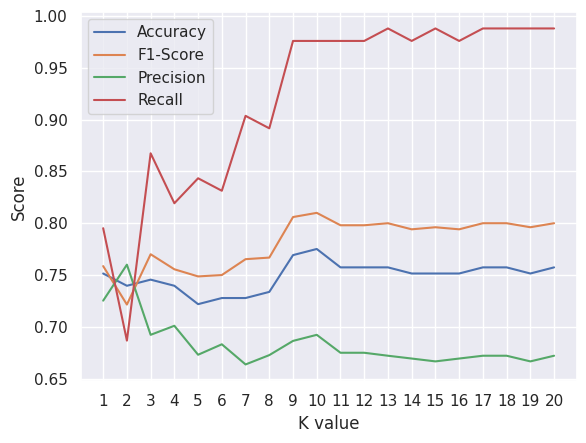

KNN Best Accuracy: 77.51%
KNN Best F1-Score: 0.81
KNN Best Precision: 0.76
KNN Best Recall: 0.99


In [186]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import numpy as np

scoreListKNN = []
f1ListKNN = []
precisionListKNN = []
recallListKNN = []

for i in range(1, 21):
    KNclassifier = KNeighborsClassifier(n_neighbors=i)
    KNclassifier.fit(X_train, y_train)

    y_pred = KNclassifier.predict(X_test)

    acc = KNclassifier.score(X_test, y_test)
    f1 = f1_score(y_test, y_pred, average='binary')
    precision = precision_score(y_test, y_pred, average='binary')
    recall = recall_score(y_test, y_pred, average='binary')

    scoreListKNN.append(acc)
    f1ListKNN.append(f1)
    precisionListKNN.append(precision)
    recallListKNN.append(recall)

# الرسم لكل المقاييس
plt.plot(range(1, 21), scoreListKNN, label="Accuracy")
plt.plot(range(1, 21), f1ListKNN, label="F1-Score")
plt.plot(range(1, 21), precisionListKNN, label="Precision")
plt.plot(range(1, 21), recallListKNN, label="Recall")
plt.xticks(np.arange(1, 21, 1))
plt.xlabel("K value")
plt.ylabel("Score")
plt.legend()
plt.show()

# أفضل القيم
print("KNN Best Accuracy: {:.2f}%".format(max(scoreListKNN)*100))
print("KNN Best F1-Score: {:.2f}".format(max(f1ListKNN)))
print("KNN Best Precision: {:.2f}".format(max(precisionListKNN)))
print("KNN Best Recall: {:.2f}".format(max(recallListKNN)))


## 6.3 Support Vector Machine (SVM)

In [187]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
SVCclassifier = SVC(kernel='rbf', max_iter=500)
SVCclassifier.fit(X_train, y_train)

y_pred = SVCclassifier.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

from sklearn.metrics import accuracy_score
SVCAcc = accuracy_score(y_pred,y_test)
print('SVC accuracy: {:.2f}%'.format(SVCAcc*100))

              precision    recall  f1-score   support

           0       0.98      0.52      0.68        86
           1       0.67      0.99      0.80        83

    accuracy                           0.75       169
   macro avg       0.82      0.76      0.74       169
weighted avg       0.83      0.75      0.74       169

[[45 41]
 [ 1 82]]
SVC accuracy: 75.15%


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=500).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


## 6.4 Naive Bayes

### 6.4.1 Categorical NB

In [188]:
NBclassifier1 = CategoricalNB()
NBclassifier1.fit(X_train, y_train)

y_pred = NBclassifier1.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

from sklearn.metrics import accuracy_score
NBAcc1 = accuracy_score(y_pred,y_test)
print('Categorical Naive Bayes accuracy: {:.2f}%'.format(NBAcc1*100))

              precision    recall  f1-score   support

           0       0.96      0.64      0.77        86
           1       0.72      0.98      0.83        83

    accuracy                           0.80       169
   macro avg       0.84      0.81      0.80       169
weighted avg       0.85      0.80      0.80       169

[[55 31]
 [ 2 81]]
Categorical Naive Bayes accuracy: 80.47%


### 6.4.2 Gaussian NB

In [189]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
NBclassifier2 = GaussianNB()
NBclassifier2.fit(X_train, y_train)

y_pred = NBclassifier2.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

from sklearn.metrics import accuracy_score
NBAcc2 = accuracy_score(y_pred,y_test)
print('Gaussian Naive Bayes accuracy: {:.2f}%'.format(NBAcc2*100))

              precision    recall  f1-score   support

           0       0.96      0.52      0.68        86
           1       0.66      0.98      0.79        83

    accuracy                           0.75       169
   macro avg       0.81      0.75      0.73       169
weighted avg       0.81      0.75      0.73       169

[[45 41]
 [ 2 81]]
Gaussian Naive Bayes accuracy: 74.56%


## 6.5 Decision Tree

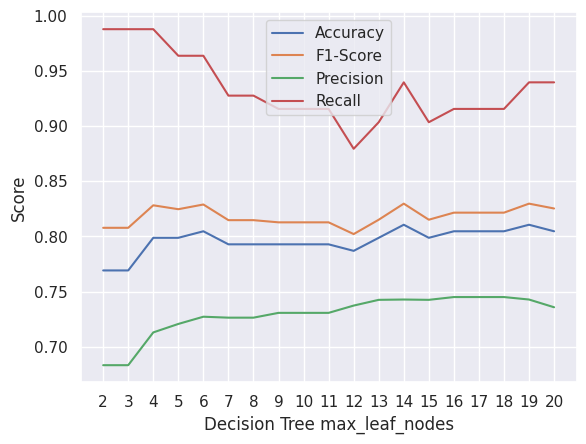

Decision Tree Best Accuracy: 81.07%
Decision Tree Best F1-Score: 0.83
Decision Tree Best Precision: 0.75
Decision Tree Best Recall: 0.99


In [190]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import numpy as np

scoreListDT = []
f1ListDT = []
precisionListDT = []
recallListDT = []

for i in range(2, 21):
    DTclassifier = DecisionTreeClassifier(max_leaf_nodes=i, random_state=1)
    DTclassifier.fit(X_train, y_train)

    y_pred = DTclassifier.predict(X_test)

    acc = DTclassifier.score(X_test, y_test)
    f1 = f1_score(y_test, y_pred, average='binary')
    precision = precision_score(y_test, y_pred, average='binary')
    recall = recall_score(y_test, y_pred, average='binary')

    scoreListDT.append(acc)
    f1ListDT.append(f1)
    precisionListDT.append(precision)
    recallListDT.append(recall)

# الرسم
plt.plot(range(2, 21), scoreListDT, label="Accuracy")
plt.plot(range(2, 21), f1ListDT, label="F1-Score")
plt.plot(range(2, 21), precisionListDT, label="Precision")
plt.plot(range(2, 21), recallListDT, label="Recall")
plt.xticks(np.arange(2, 21, 1))
plt.xlabel("Decision Tree max_leaf_nodes")
plt.ylabel("Score")
plt.legend()
plt.show()

# أفضل القيم
print("Decision Tree Best Accuracy: {:.2f}%".format(max(scoreListDT)*100))
print("Decision Tree Best F1-Score: {:.2f}".format(max(f1ListDT)))
print("Decision Tree Best Precision: {:.2f}".format(max(precisionListDT)))
print("Decision Tree Best Recall: {:.2f}".format(max(recallListDT)))


## 6.6 Random Forest

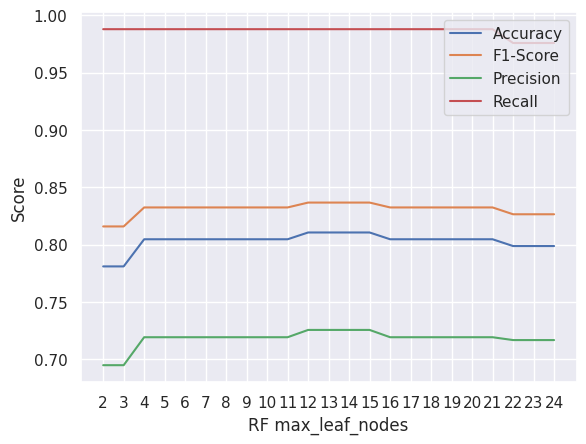

Random Forest Best Accuracy: 81.07%
Random Forest Best F1-Score: 0.84
Random Forest Best Precision: 0.73
Random Forest Best Recall: 0.99


In [191]:
from sklearn.metrics import f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier

scoreListRF = []
f1ListRF = []
precisionListRF = []
recallListRF = []

for i in range(2, 25):
    RFclassifier = RandomForestClassifier(n_estimators=1000, random_state=1, max_leaf_nodes=i)
    RFclassifier.fit(X_train, y_train)

    # التوقعات
    y_pred = RFclassifier.predict(X_test)

    # الحسابات
    acc = RFclassifier.score(X_test, y_test)
    f1 = f1_score(y_test, y_pred, average='binary')
    precision = precision_score(y_test, y_pred, average='binary')
    recall = recall_score(y_test, y_pred, average='binary')

    # تخزين
    scoreListRF.append(acc)
    f1ListRF.append(f1)
    precisionListRF.append(precision)
    recallListRF.append(recall)

# الرسم
plt.plot(range(2, 25), scoreListRF, label="Accuracy")
plt.plot(range(2, 25), f1ListRF, label="F1-Score")
plt.plot(range(2, 25), precisionListRF, label="Precision")
plt.plot(range(2, 25), recallListRF, label="Recall")
plt.xticks(np.arange(2, 25, 1))
plt.xlabel("RF max_leaf_nodes")
plt.ylabel("Score")
plt.legend()
plt.show()

# أفضل القيم
print("Random Forest Best Accuracy: {:.2f}%".format(max(scoreListRF)*100))
print("Random Forest Best F1-Score: {:.2f}".format(max(f1ListRF)))
print("Random Forest Best Precision: {:.2f}".format(max(precisionListRF)))
print("Random Forest Best Recall: {:.2f}".format(max(recallListRF)))


## 6.7 Gradient Boosting

In [192]:
paramsGB={'n_estimators':[100,200,300,400,500],
      'max_depth':[1,2,3,4,5],
      'subsample':[0.5,1],
      'max_leaf_nodes':[2,5,10,20,30,40,50]}

In [193]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
GB = RandomizedSearchCV(GradientBoostingClassifier(), paramsGB, cv=20)
GB.fit(X_train, y_train)

RandomizedSearchCV(cv=20, estimator=GradientBoostingClassifier(),
                   param_distributions={'max_depth': [1, 2, 3, 4, 5],
                                        'max_leaf_nodes': [2, 5, 10, 20, 30, 40,
                                                           50],
                                        'n_estimators': [100, 200, 300, 400,
                                                         500],
                                        'subsample': [0.5, 1]})

In [194]:
print(GB.best_estimator_)
print(GB.best_score_)
print(GB.best_params_)
print(GB.best_index_)

GradientBoostingClassifier(max_depth=4, max_leaf_nodes=20, n_estimators=200,
                           subsample=0.5)
0.8368983957219251
{'subsample': 0.5, 'n_estimators': 200, 'max_leaf_nodes': 20, 'max_depth': 4}
3


In [195]:
GBclassifier = GradientBoostingClassifier(subsample=0.5, n_estimators=400, max_depth=4, max_leaf_nodes=10)
GBclassifier.fit(X_train, y_train)

y_pred = GBclassifier.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

from sklearn.metrics import accuracy_score
GBAcc = accuracy_score(y_pred,y_test)
print('Gradient Boosting accuracy: {:.2f}%'.format(GBAcc*100))

              precision    recall  f1-score   support

           0       0.90      0.73      0.81        86
           1       0.77      0.92      0.84        83

    accuracy                           0.82       169
   macro avg       0.83      0.82      0.82       169
weighted avg       0.84      0.82      0.82       169

[[63 23]
 [ 7 76]]
Gradient Boosting accuracy: 82.25%


# 7. Model Comparison

In [196]:
compare = pd.DataFrame({
    'Model': ['Logistic Regression', 'K Neighbors',
              'SVM', 'Gaussian NB',
              'Decision Tree', 'Gradient Boost'],
    'Accuracy': [LRAcc*100, KNAcc*100, SVCAcc*100,
                 NBAcc2*100, DTAcc*100, GBAcc*100]  # NBAcc2 لأن Gaussian NB هو اللي استخدمناه
})

compare = compare.sort_values(by='Accuracy', ascending=False)
compare


,Model,Accuracy
1,K Neighbors,82.840237
5,Gradient Boost,82.248521
0,Logistic Regression,78.106509
4,Decision Tree,76.923077
2,SVM,75.147929
3,Gaussian NB,74.556213


# Let's see the feature importance

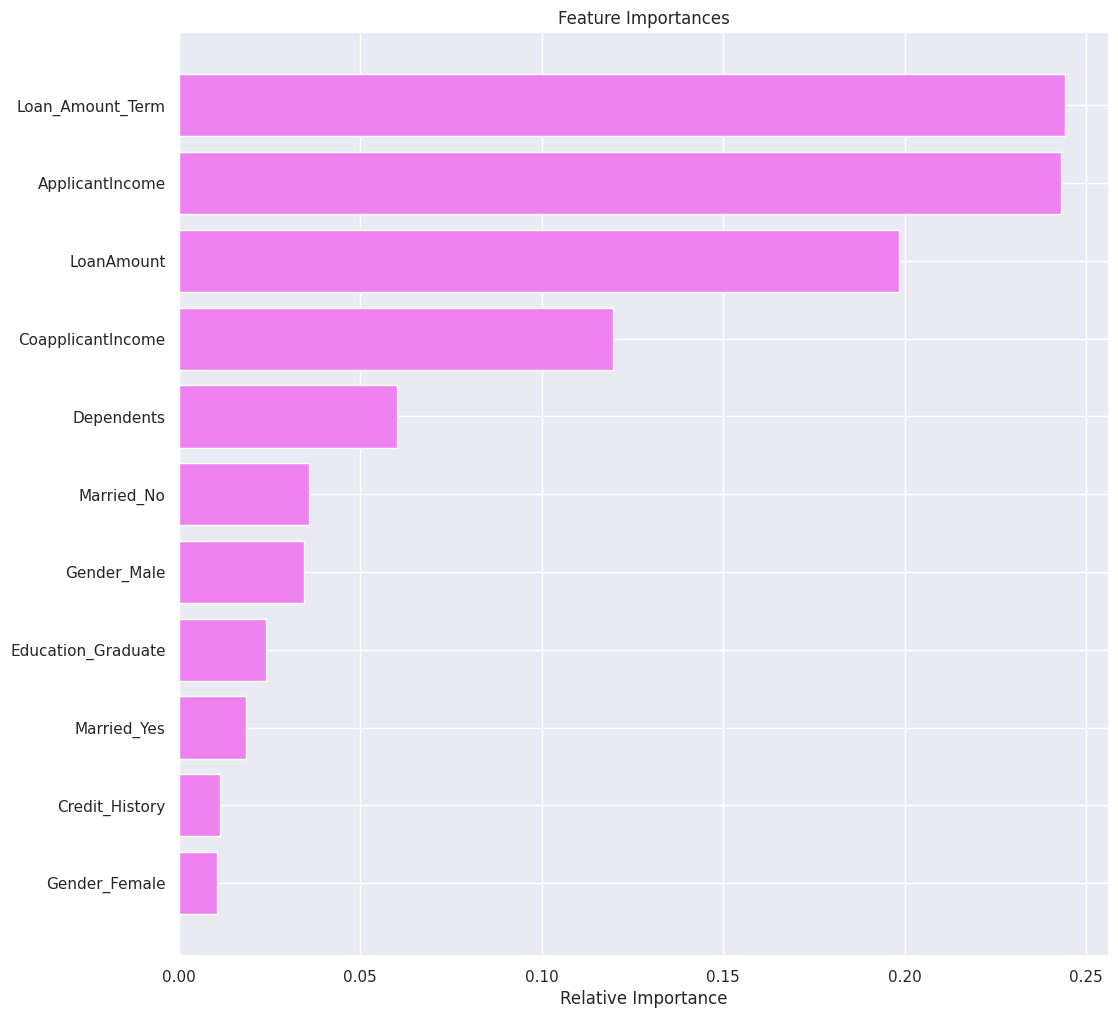

In [197]:
feature_names = X.columns
importances = GBclassifier.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()


# Lookind For Neural network??

In [198]:
import keras
from keras import backend as K
from keras.models import Sequential
from tensorflow.keras.optimizers import *
from tensorflow.keras.utils import *
from tensorflow.keras.callbacks import *
from tensorflow.keras.initializers import *
from tensorflow.keras import regularizers

from tensorflow.keras.layers import Dense
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.metrics import CategoricalAccuracy


In [199]:
n_inputs = X_train.shape[1]

model = Sequential([
    Dense(n_inputs, input_shape=(n_inputs, ), activation='relu'),
    Dense(32, activation='relu'),
    Dense(2, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [200]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 582 (2.27 KB)

 Trainable params: 582 (2.27 KB)

 Non-trainable params: 0 (0.00 B)

In [201]:
model.compile(Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [202]:
model.fit(X_train, y_train, validation_data=(X_test,y_test), batch_size=25,
          epochs=150, shuffle=True, verbose=1)

Epoch 1/150
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5302 - loss: 0.6788 - val_accuracy: 0.6154 - val_loss: 0.6580
Epoch 2/150
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5894 - loss: 0.6615 - val_accuracy: 0.6450 - val_loss: 0.6379
Epoch 3/150
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6534 - loss: 0.6293 - val_accuracy: 0.6686 - val_loss: 0.6075
Epoch 4/150
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6696 - loss: 0.6112 - val_accuracy: 0.7041 - val_loss: 0.5798
Epoch 5/150
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7616 - loss: 0.5511 - val_accuracy: 0.7041 - val_loss: 0.5554
Epoch 6/150
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7445 - loss: 0.5328 - val_accuracy: 0.7574 - val_loss: 0.5334
Epoch 7/150
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7678 - loss: 0.5214 - val_accuracy: 0.7456 - val_loss: 0.5120
Epoch 8/150
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7753 - loss: 0.4857 - val_accuracy: 0.7633 - 

In [203]:
predictions = model.predict(X_test, batch_size=200, verbose=0)

In [204]:
#Get predicted probabilities for all classes
y_pred_prob = model.predict(X_test)

# Pick the class with highest probability
y_pred = np.argmax(y_pred_prob, axis=1)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


In [205]:
import itertools

# Create a confusion matrix
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title, fontsize=14)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

Confusion matrix, without normalization
[[47 39]
 [ 3 80]]
Confusion matrix, without normalization
[[86  0]
 [ 0 83]]


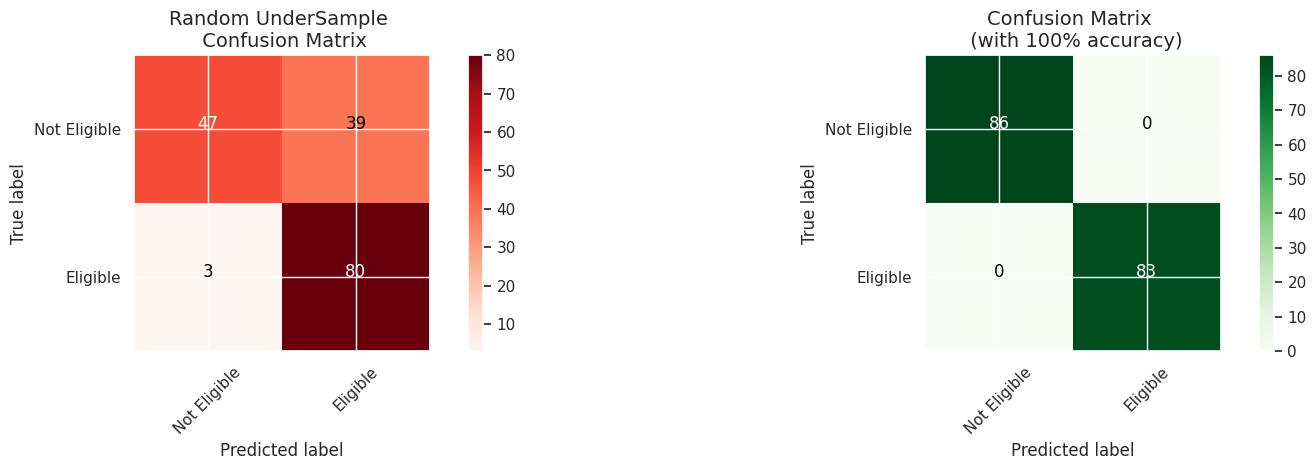

In [206]:
pred_cm = confusion_matrix(y_test, y_pred)
actual_cm = confusion_matrix(y_test, y_test)
labels = ['Not Eligible', 'Eligible']

fig = plt.figure(figsize=(16,8))

fig.add_subplot(221)
plot_confusion_matrix(pred_cm, labels, title="Random UnderSample \n Confusion Matrix", cmap=plt.cm.Reds)

fig.add_subplot(222)
plot_confusion_matrix(actual_cm, labels, title="Confusion Matrix \n (with 100% accuracy)", cmap=plt.cm.Greens)